# Instrumental Variables (IV)

In many scenarios, the treatment is not assigned randomly, and there are unobserved confounders that affect both the treatment and the outcome. In such cases, we can use an Instrumental Variable (IV) to estimate the Local Average Treatment Effect (LATE).

# Causal Assumptions

**First-stage strength**: instruments must be strongly correlated with the treatment.

**Reduced form**: instrument must affect the outcome only through the treatment.

**Instrument balance by Z**: instrument should be as good as random, independent of confounders.

**Instrument propensity / predictability**: instrument assignment should not be perfectly predictable from observed confounders.

**Subgroup first-stage stability**

**Correct time order: X before Z, Z before D, D before Y**: by design

# Data

For the analysis you need data in pandas dataframe:
- treatment column in binary format (1/0)
- outcome column numeric format, measured after treatment time
- instruments column in binary format (1/0), measured before treatment time
- user_id column (Optional, but useful)
- confounders columns (Optional, measured before instrument time, numeric format, used for causal assumption check)

We will use the `generate_offer_iv_26` DGP from `causalis`

In [1]:
from causalis.scenarios.iv.dgp import generate_offer_iv_26
from causalis.data_contracts.iv_causal_data import IVCausalData

# Generate data
data = generate_offer_iv_26(n=20000, return_causal_data=False, include_oracle=True)
data.head()

,user_id,net_revenue_90d,accepted_offer,offer_eligible,age,tenure_months,annual_income,credit_score,app_sessions_30d,prior_spend_30d,...,g_z0,g_z1,iv_first_stage,iv_reduced_form,late_x,late,tau_link,g_d0,g_d1,cate
0,030f6,48.279955,0.0,0.0,42.0,39.154939,31608.240102,608.0,8.0,135.193819,...,33.125526,37.110160,0.254016,3.984633,15.686553,16.939349,15.686553,31.032649,46.719202,15.686553
1,03f52,39.719108,0.0,0.0,37.0,32.736592,214134.071780,727.0,4.0,491.348038,...,80.788151,88.054619,0.330043,7.266468,22.016741,16.939349,22.016741,72.536790,94.553531,22.016741
2,02ba6,49.727505,0.0,0.0,55.0,21.023638,95958.504507,643.0,7.0,189.244171,...,54.183327,58.871145,0.295717,4.687818,15.852359,16.939349,15.852359,51.189302,67.041662,15.852359
3,02e17,72.155483,1.0,1.0,25.0,18.105017,35715.886364,617.0,11.0,187.196966,...,66.779471,74.938408,0.331056,8.158937,24.645154,16.939349,24.645154,57.819237,82.464391,24.645154
4,0443a,33.330021,0.0,0.0,19.0,62.996281,107316.360040,691.0,2.0,113.817846,...,50.285174,54.246284,0.286149,3.961110,13.842813,16.939349,13.842813,47.884921,61.727734,13.842813


In [2]:
causal_data = IVCausalData.from_df(
    df=data,
    treatment='accepted_offer',
    outcome='net_revenue_90d',
    instruments='offer_eligible',
    confounders=[
        'age', 'tenure_months', 'annual_income', 'credit_score', 
        'app_sessions_30d', 'prior_spend_30d', 'savings_balance', 
        'premium_user', 'autopay_enabled', 'region_north', 
        'region_west', 'acquisition_paid'
    ],
    user_id='user_id'
)
causal_data

IVCausalData(df=(20000, 16), treatment='accepted_offer', outcome='net_revenue_90d', instruments=['offer_eligible'], confounders=['age', 'tenure_months', 'annual_income', 'credit_score', 'app_sessions_30d', 'prior_spend_30d', 'savings_balance', 'premium_user', 'autopay_enabled', 'region_north', 'region_west', 'acquisition_paid'], user_id='user_id')

# EDA

In [3]:
from causalis.shared import outcome_stats, outcome_plot_dist, confounders_balance

outcome_stats(causal_data)

,treatment,count,mean,std,min,p10,p25,median,p75,p90,max
0,0,13215,38.494730,25.145975,-49.067110,6.322963,21.665921,38.406990,55.429396,70.823578,137.335543
1,1,6785,73.709423,27.678527,-33.508289,38.841811,54.860868,73.235466,92.284659,109.586879,170.766350


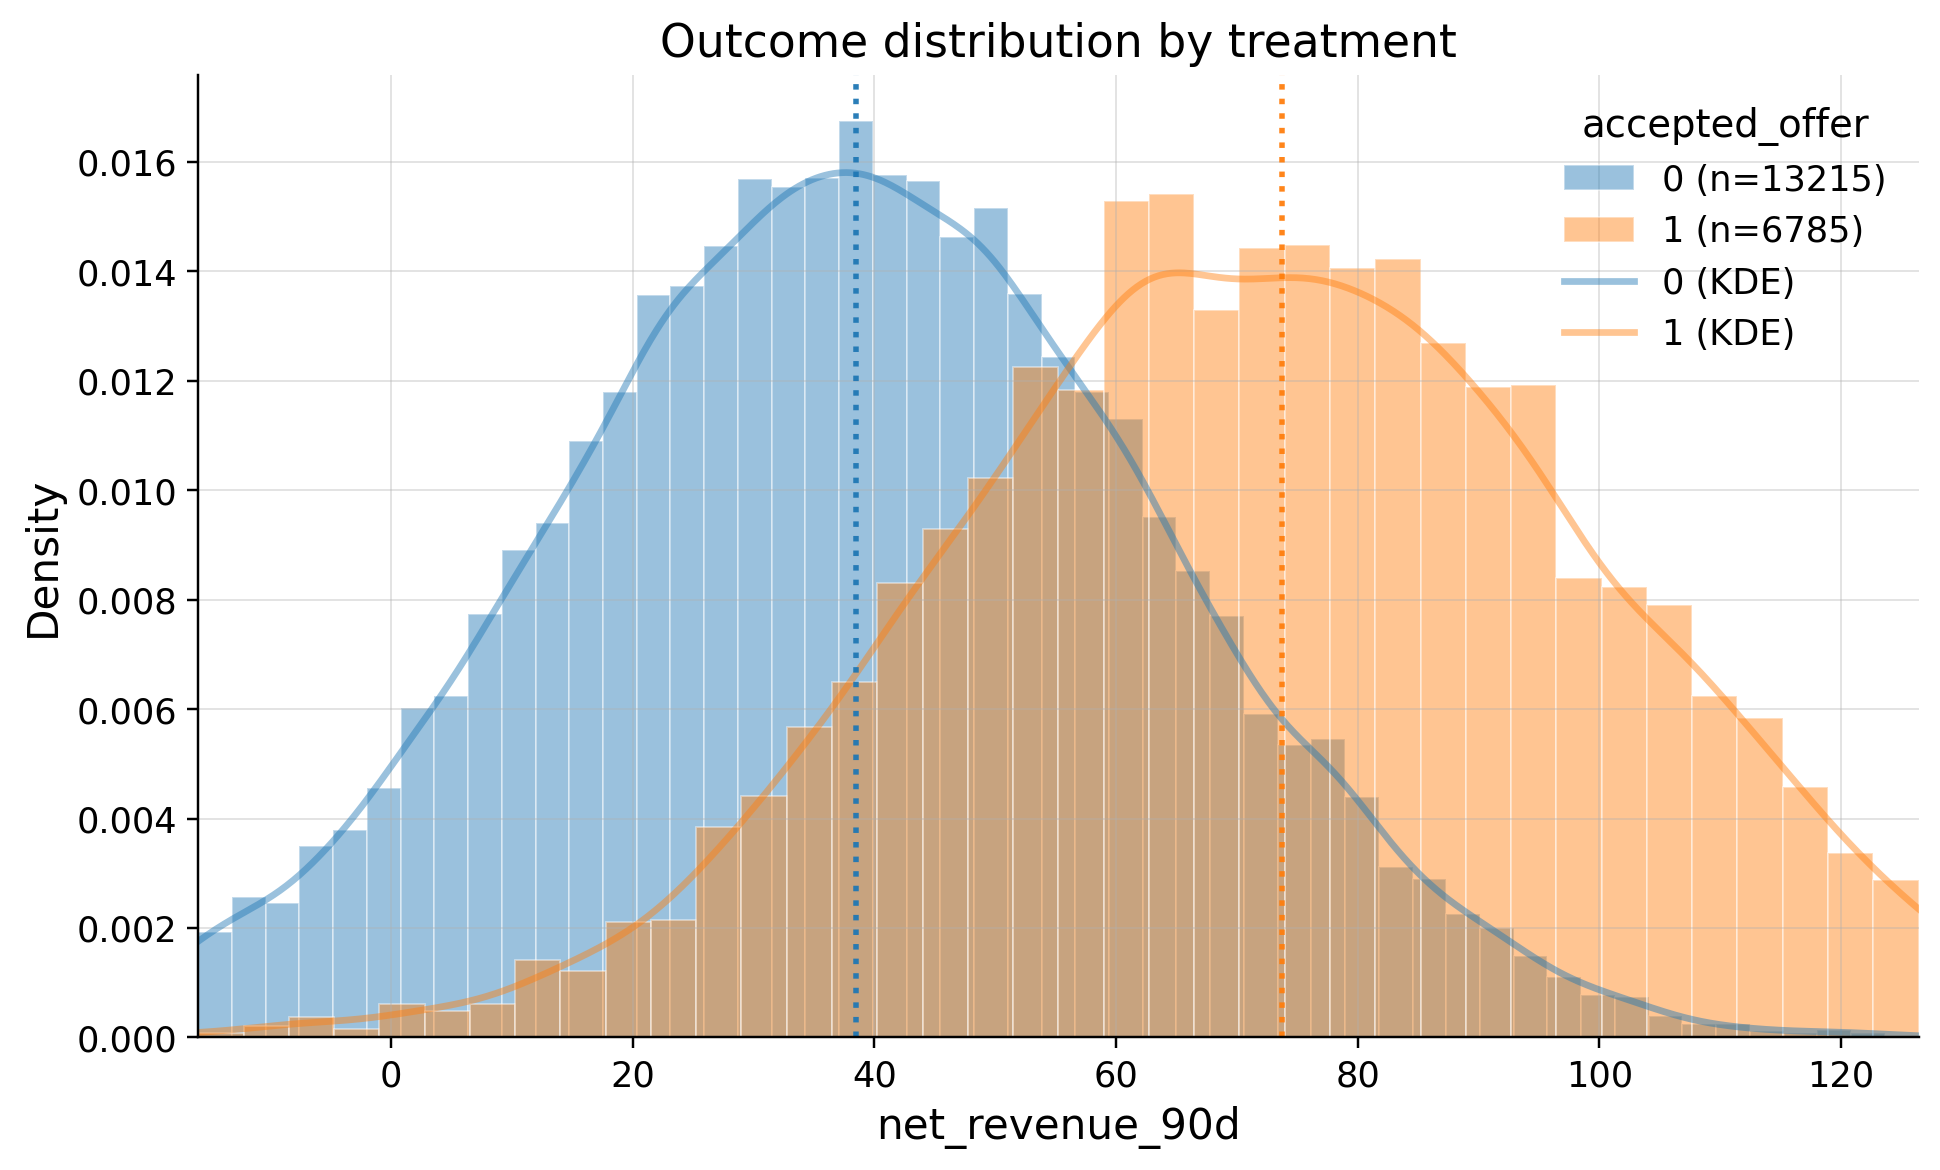

In [4]:
outcome_plot_dist(causal_data)

## Check the confounders balance for the instrument

Are groups equal in terms of confounders? We check the balance of confounders across the instrument assignment (`offer_eligible`).

In [5]:
from causalis.scenarios.iv.refutation import iv_confounders_balance
iv_confounders_balance(causal_data)

,confounders,mean_z_0,mean_z_1,abs_diff,smd,ks_pvalue
0,credit_score,659.763925,693.257527,33.493602,0.532581,0.00000
1,annual_income,84199.971125,99330.828981,15130.857856,0.286549,0.00000
2,tenure_months,28.492666,32.022261,3.529595,0.180959,0.00000
3,autopay_enabled,0.357290,0.444624,0.087334,0.178902,0.00000
4,premium_user,0.241589,0.313763,0.072175,0.161675,0.00000
5,acquisition_paid,0.451963,0.377312,0.074651,-0.151955,0.00000
6,savings_balance,7027.452482,8913.472089,1886.019607,0.151898,0.00000
7,prior_spend_30d,156.527119,172.979941,16.452822,0.110804,0.00000
8,age,37.699533,38.662581,0.963048,0.087552,0.00000
9,app_sessions_30d,7.218411,7.526022,0.307610,0.072912,0.00018


# Inference

In [6]:
from causalis.scenarios.iv.model import IIVM

model = IIVM()
model.fit(causal_data)

IIVM(status='fitted', n_folds=5, random_state=None)

In [7]:
result = model.estimate(score="LATE")
result.summary()

,value
field,
estimand,LATE
model,IIVM
value,"19.1385 (ci_abs: 16.9702, 21.3068)"
value_relative,None
std_error,1.1063
t_stat,17.2999
alpha,0.0500
p_value,0.0000
is_significant,True


# Diagnostics

In [8]:
from causalis.scenarios.iv.refutation import (
    first_stage,
    instrument_overlap,
    instrument_overlap_plot,
    reduced_form,
)

In [9]:
first_stage(result)

,metric,value,flag,threshold,message
0,first_stage_effect,0.282397,GREEN,GREEN F >= 10; YELLOW 4 <= F < 10; RED F < 4 o...,Coefficient on Z in D ~ 1 + Z + X.
1,first_stage_se,0.006291,GREEN,GREEN when finite; RED when unavailable or inv...,HC1 robust standard error for the Z coefficient.
2,first_stage_pvalue,0.0,GREEN,GREEN when finite; RED when unavailable or inv...,HC1 robust p-value for the Z coefficient.
3,first_stage_f,2015.048215,GREEN,GREEN F >= 10; YELLOW 4 <= F < 10; RED F < 4 o...,Robust first-stage Wald F for the single instr...
4,partial_r2,0.095442,GREEN,GREEN when finite; RED when unavailable or inv...,Partial R-squared added by Z after controlling...
5,orthogonal_first_stage,0.281294,GREEN,GREEN F >= 10; YELLOW 4 <= F < 10; RED F < 4 o...,Denominator of the orthogonal LATE score.
6,weak_iv_flag,GREEN,GREEN,GREEN F >= 10; YELLOW 4 <= F < 10; RED F < 4 o...,First stage is strong enough for IV inference.


In [10]:
instrument_overlap(result)

,metric,value,flag,threshold,message
0,instrument_auc,0.653257,YELLOW,GREEN <0.60; YELLOW 0.60-0.75; RED >0.75 by ma...,How well covariates predict the instrument; hi...
1,instrument_propensity_ks,0.226303,GREEN,GREEN <=0.30; YELLOW >0.30-0.40; RED >0.40,Two-sample KS distance between Z=1 and Z=0 pro...
2,instrument_ess_ratio,0.813130,GREEN,GREEN >=0.30; YELLOW 0.15-0.30; RED <0.15,Minimum observed-arm IPW effective-sample-size...


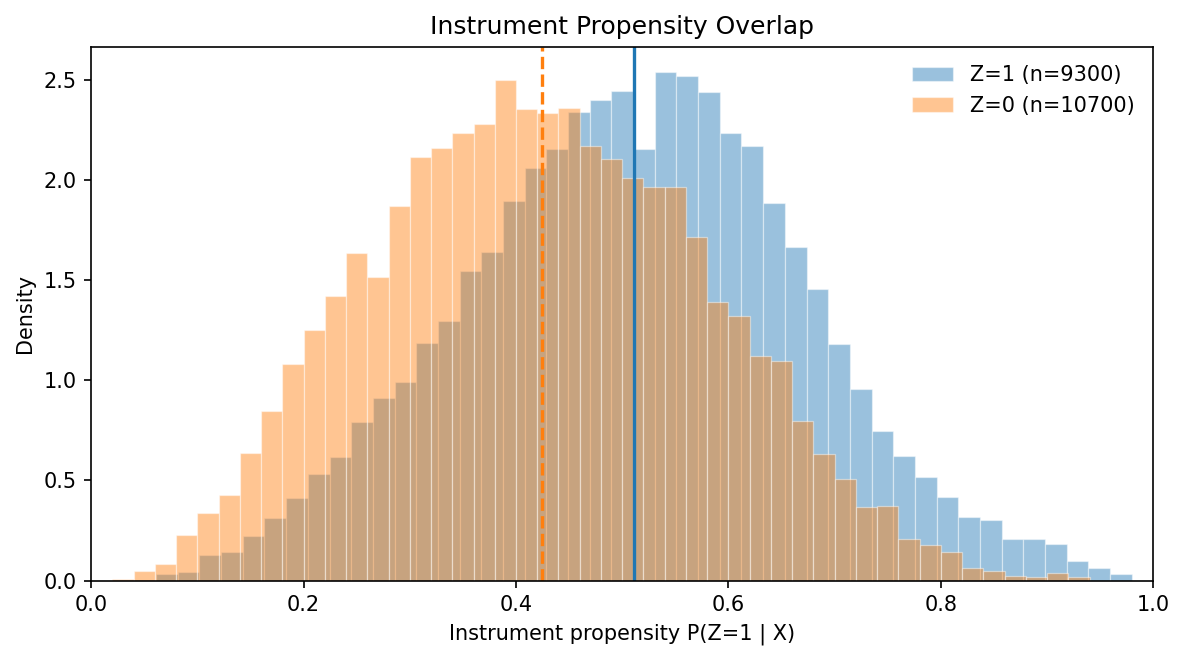

In [11]:
instrument_overlap_plot(result)

In [12]:
reduced_form(result)

,metric,value,flag,threshold,message
0,reduced_form_effect,1.076413e+01,GREEN,GREEN when finite; RED when unavailable or inv...,Coefficient on Z in Y ~ 1 + Z.
1,reduced_form_se,4.336784e-01,GREEN,GREEN when finite; RED when unavailable or inv...,HC1 robust standard error for the reduced-form...
2,reduced_form_pvalue,5.379896e-136,GREEN,GREEN when finite; RED when unavailable or inv...,HC1 robust p-value; non-significance is not a ...
3,orthogonal_reduced_form,5.383544e+00,GREEN,GREEN when finite; RED when unavailable or inv...,Numerator of the orthogonal LATE score.
4,late_ratio_check,1.913849e+01,GREEN,GREEN when finite; RED when unavailable or inv...,Orthogonal reduced form divided by orthogonal ...


# Refutation

let's compare with oracle effect

In [13]:
print(f"Ground truth LATE (oracle) is {data['late'].mean()}")

Ground truth LATE (oracle) is 16.939348789576744
